# PROJECT INTRODUCTION

In [ ]:
# Employee Attrition Analysis and Prediction

## Objective
The goal of this project is to analyze employee attrition patterns and build a machine learning model to predict whether an employee is likely to leave the company.

## Business Problem
Employee attrition causes major financial and productivity losses for organizations. By identifying the main reasons behind attrition, HR teams can take preventive actions.

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn

# IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.style.use('ggplot')

np.random.seed(42)

# load dataset

In [23]:
try:
    df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("Dataset file not found")

Dataset loaded successfully


# display data set

In [24]:
print(df.head())

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLevel  \
0  ...

# DATASET INFORMATION

In [25]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

# CHECK MISSING VALUES

In [26]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

# STATISTICAL SUMMARY

In [27]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

# CATEGORICAL SUMMARY

In [28]:
print(df.describe(include='object'))

       Attrition BusinessTravel              Department EducationField Gender  \
count       1470           1470                    1470           1470   1470   
unique         2              3                       3              6      2   
top           No  Travel_Rarely  Research & Development  Life Sciences   Male   
freq        1233           1043                     961            606    882   

                JobRole MaritalStatus Over18 OverTime  
count              1470          1470   1470     1470  
unique                9             3      1        2  
top     Sales Executive       Married      Y       No  
freq                326           673   1470     1054  


# CHECK DUPLICATES

In [29]:
print(f"Duplicate Rows: {df.duplicated().sum()}")

Duplicate Rows: 0


#  DATA CLEANING

In [30]:
drop_cols = [
    'EmployeeCount',
    'EmployeeNumber',
    'Over18',
    'StandardHours'
]

df.drop(columns=drop_cols, inplace=True)

print("Columns removed successfully")

Columns removed successfully


# TARGET VARIABLE ENCODING

In [31]:

le = LabelEncoder()

df['AttritionFlag'] = le.fit_transform(df['Attrition'])

print(df[['Attrition', 'AttritionFlag']].head())

  Attrition  AttritionFlag
0       Yes              1
1        No              0
2       Yes              1
3        No              0
4        No              0


# ATTRITION DISTRIBUTION

In [32]:
print(df['AttritionFlag'].value_counts())

AttritionFlag
0    1233
1     237
Name: count, dtype: int64


# ATTRITION PERCENTAGE

In [33]:
print(df['AttritionFlag'].value_counts(normalize=True) * 100)

AttritionFlag
0    83.877551
1    16.122449
Name: proportion, dtype: float64


# ATTRITION VISUALIZATION

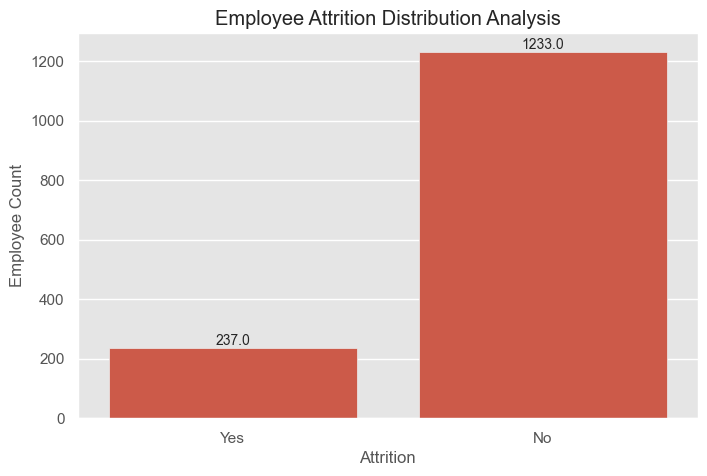

In [34]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Attrition', data=df)

for p in ax.patches:
    ax.annotate(f'{p.get_height()}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Employee Attrition Distribution Analysis')
plt.xlabel('Attrition')
plt.ylabel('Employee Count')

plt.show()

# AGE DISTRIBUTION

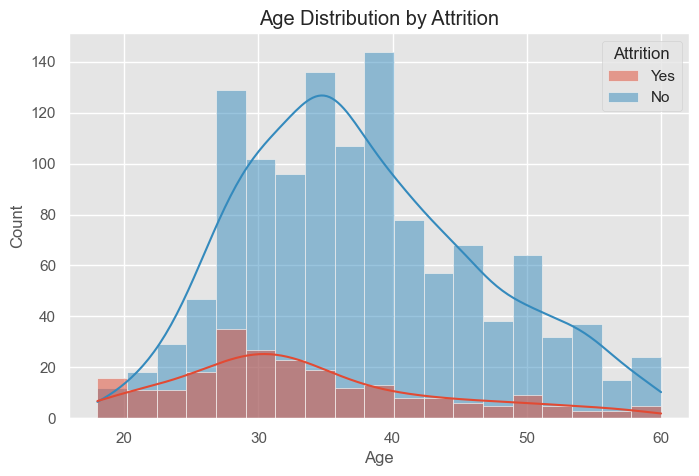

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x='Age', hue='Attrition', kde=True)

plt.title('Age Distribution by Attrition')
plt.show()

# MONTHLY INCOME ANALYSIS

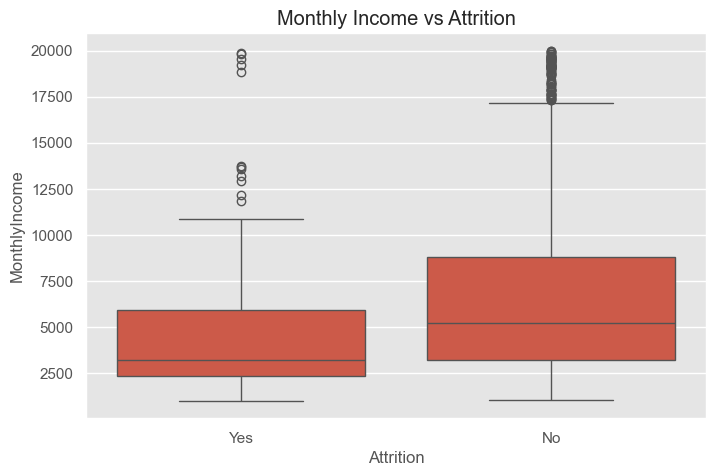

In [36]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)

plt.title('Monthly Income vs Attrition')
plt.show()

# OVERTIME ANALYSIS

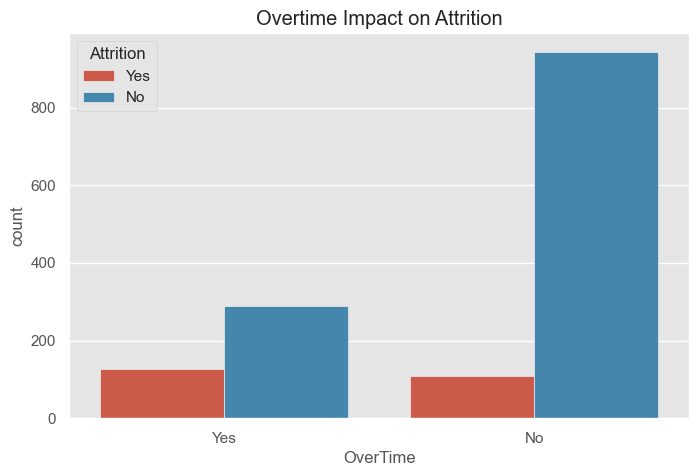

In [37]:
plt.figure(figsize=(8,5))

sns.countplot(x='OverTime', hue='Attrition', data=df)

plt.title('Overtime Impact on Attrition')
plt.show()

# JOB SATISFACTION ANALYSIS

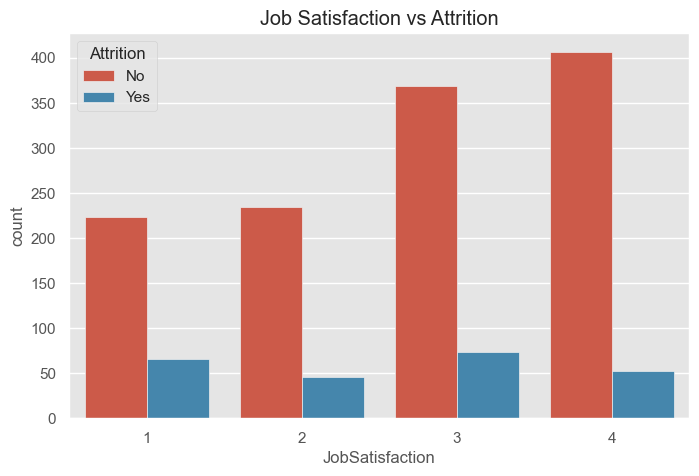

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(x='JobSatisfaction', hue='Attrition', data=df)

plt.title('Job Satisfaction vs Attrition')
plt.show()

# WORK LIFE BALANCE

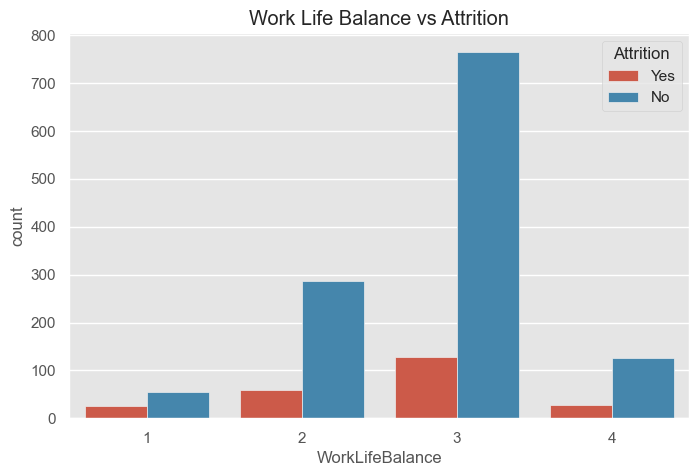

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(x='WorkLifeBalance', hue='Attrition', data=df)

plt.title('Work Life Balance vs Attrition')
plt.show()

# YEARS AT COMPANY

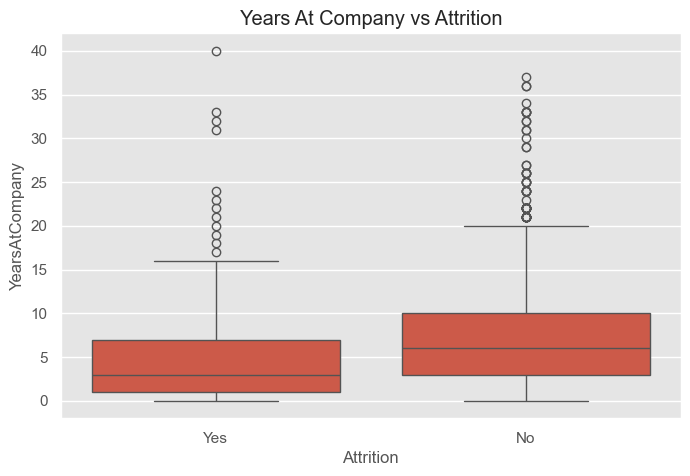

In [40]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)

plt.title('Years At Company vs Attrition')
plt.show()

# DEPARTMENT ANALYSIS

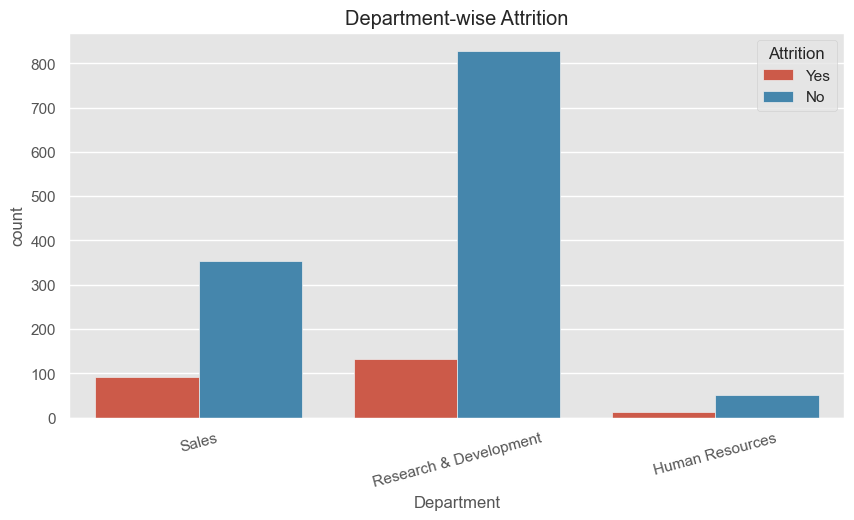

In [41]:
plt.figure(figsize=(10,5))

sns.countplot(x='Department', hue='Attrition', data=df)

plt.title('Department-wise Attrition')
plt.xticks(rotation=15)
plt.show()

# JOB ROLE ANALYSIS

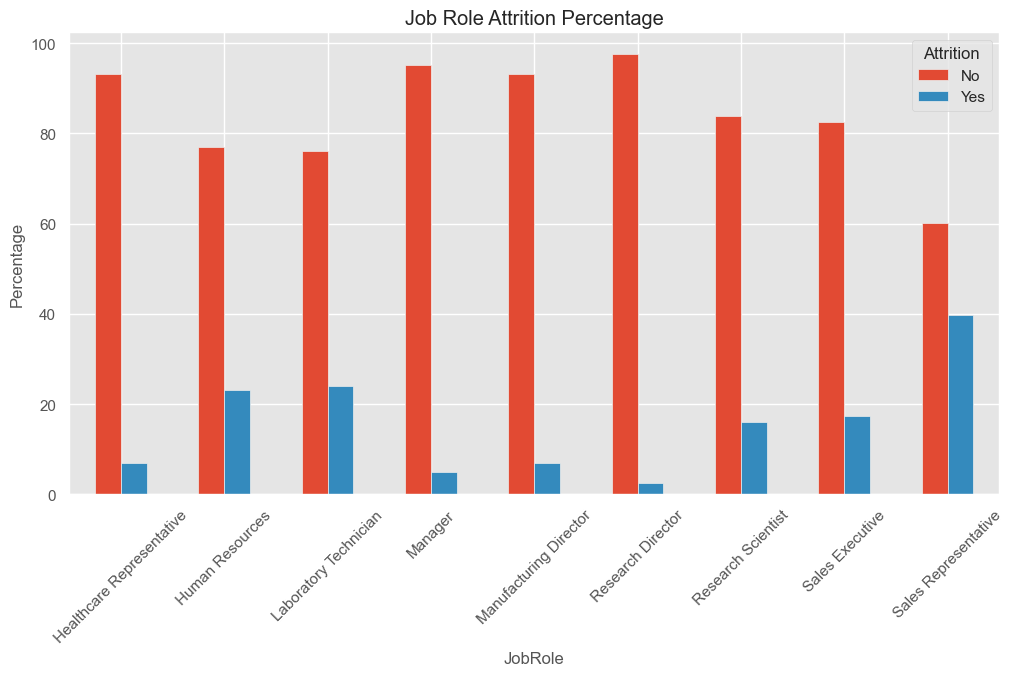

In [42]:
job_attrition = pd.crosstab(df['JobRole'], df['Attrition'], normalize='index') * 100

job_attrition.plot(kind='bar', figsize=(12,6))

plt.title('Job Role Attrition Percentage')
plt.ylabel('Percentage')
plt.xticks(rotation=45)

plt.show()

# EDUCATION FIELD ANALYSIS

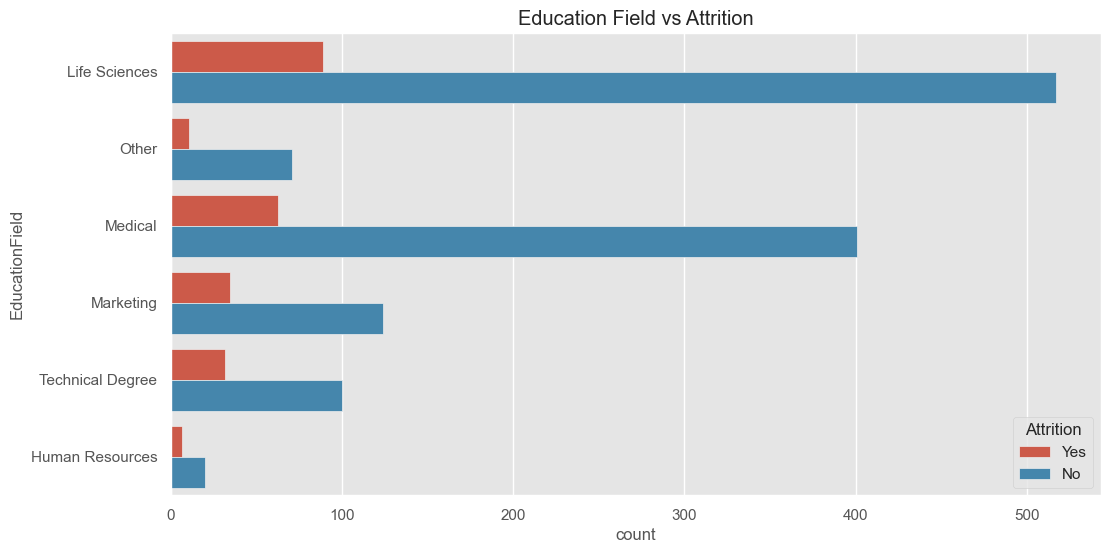

In [43]:
plt.figure(figsize=(12,6))

sns.countplot(y='EducationField', hue='Attrition', data=df)

plt.title('Education Field vs Attrition')
plt.show()

# CORRELATION ANALYSIS

In [44]:
num_cols = df.select_dtypes(include=np.number).columns

corr = df[num_cols].corr()['AttritionFlag'].abs().sort_values(ascending=False)[1:15]

print(corr)

TotalWorkingYears          0.171063
JobLevel                   0.169105
YearsInCurrentRole         0.160545
MonthlyIncome              0.159840
Age                        0.159205
YearsWithCurrManager       0.156199
StockOptionLevel           0.137145
YearsAtCompany             0.134392
JobInvolvement             0.130016
JobSatisfaction            0.103481
EnvironmentSatisfaction    0.103369
DistanceFromHome           0.077924
WorkLifeBalance            0.063939
TrainingTimesLastYear      0.059478
Name: AttritionFlag, dtype: float64


# HEATMAP

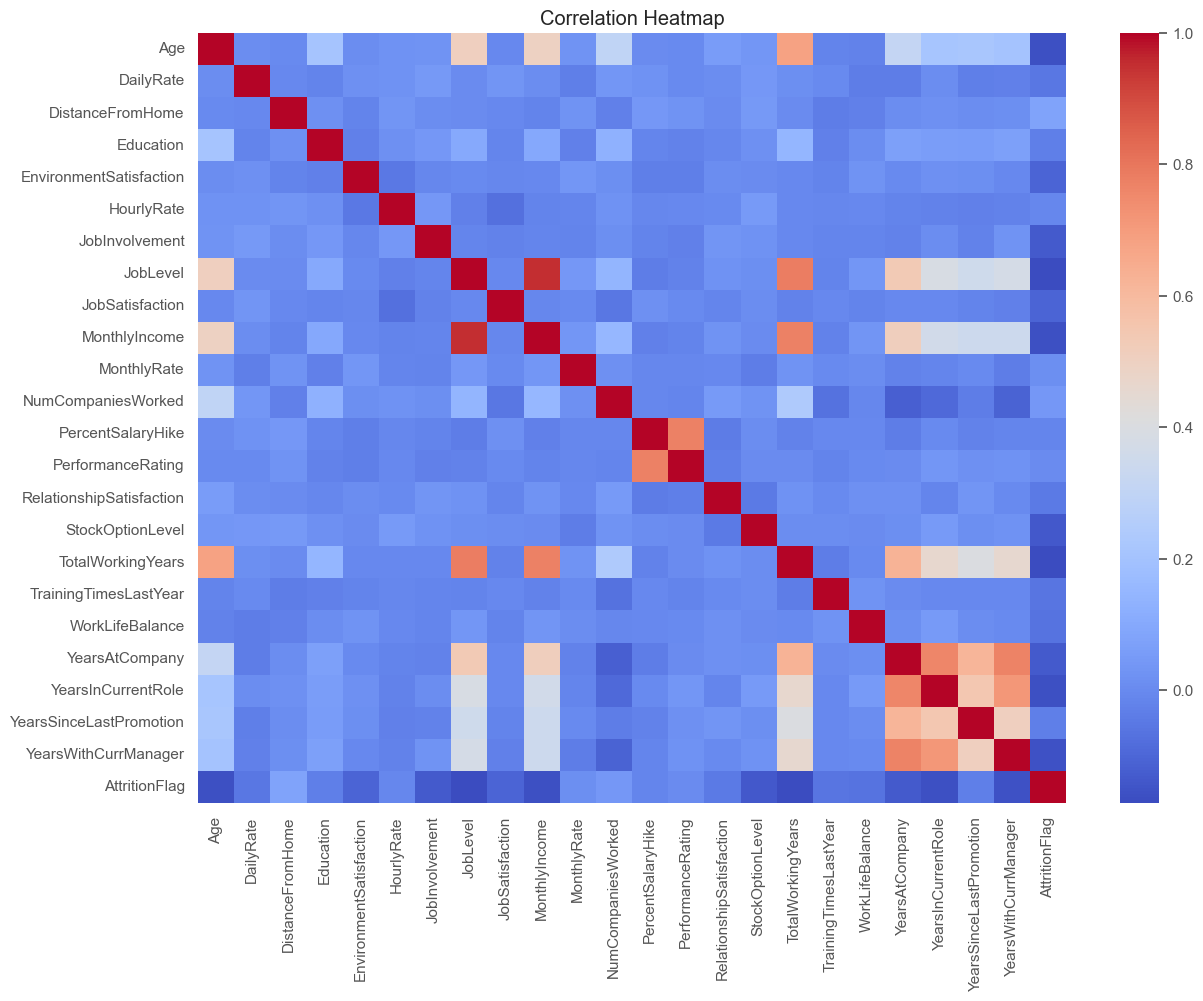

In [45]:
plt.figure(figsize=(14,10))

sns.heatmap(df[num_cols].corr(), cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

# BUSINESS INSIGHTS AND HR RECOMMENDATIONS

In [48]:
print("BUSINESS INSIGHTS")
print("-------------------------")

print("Employees working overtime are more likely to leave the company.")
print("Lower monthly income shows higher attrition trend.")
print("Sales Representatives and Laboratory Technicians show higher attrition.")
print("Poor work-life balance increases attrition risk.")
print("Lower job satisfaction contributes to employee resignation.")
print("SUGGESTED HR ACTIONS")

print("HR RECOMMENDATIONS")
print("-------------------------")

print("1. Improve employee work-life balance")
print("2. Reduce overtime burden")
print("3. Increase employee engagement")
print("4. Conduct regular employee feedback surveys")
print("5. Improve salary and retention benefits")

BUSINESS INSIGHTS
-------------------------
Employees working overtime are more likely to leave the company.
Lower monthly income shows higher attrition trend.
Sales Representatives and Laboratory Technicians show higher attrition.
Poor work-life balance increases attrition risk.
Lower job satisfaction contributes to employee resignation.
SUGGESTED HR ACTIONS
HR RECOMMENDATIONS
-------------------------
1. Improve employee work-life balance
2. Reduce overtime burden
3. Increase employee engagement
4. Conduct regular employee feedback surveys
5. Improve salary and retention benefits


# ENCODE CATEGORICAL FEATURES

In [49]:
for col in df.select_dtypes(include='object').columns:
    df[col] = LabelEncoder().fit_transform(df[col])

print("Categorical columns encoded")

Categorical columns encoded


# FEATURE AND TARGET SELECTION

In [50]:
X = df.drop(['Attrition', 'AttritionFlag'], axis=1)
y = df['AttritionFlag']

# FEATURE SCALING

In [51]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# TRAIN TEST SPLIT

In [53]:
X_train, X_test, y_train, y_test = train_test_split(    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1176, 30)
(294, 30)


# LOGISTIC REGRESSION MODEL

In [54]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# LOGISTIC REGRESSION RESULT

In [56]:
print("Logistic Regression Accuracy:")
print(accuracy_score(y_test, y_pred_lr))

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy:
0.8945578231292517
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       255
           1       0.70      0.36      0.47        39

    accuracy                           0.89       294
   macro avg       0.80      0.67      0.71       294
weighted avg       0.88      0.89      0.88       294



# CONFUSION MATRIX

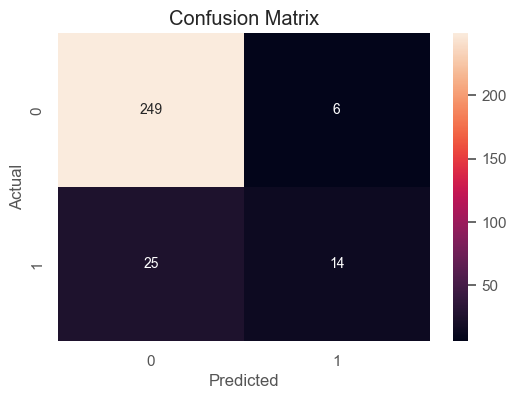

In [57]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6,4))

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# ROC AUC SCORE

In [58]:
roc_score = roc_auc_score(y_test, y_pred_lr)

print("ROC AUC Score:", roc_score)

ROC AUC Score: 0.6677224736048265


# RANDOM FOREST MODEL

In [59]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# RANDOM FOREST RESULTS

In [61]:
print("Random Forest Accuracy:")
print(accuracy_score(y_test, y_pred_rf))

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy:
0.8809523809523809
Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94       255
           1       0.83      0.13      0.22        39

    accuracy                           0.88       294
   macro avg       0.86      0.56      0.58       294
weighted avg       0.88      0.88      0.84       294



# FEATURE IMPORTANCE

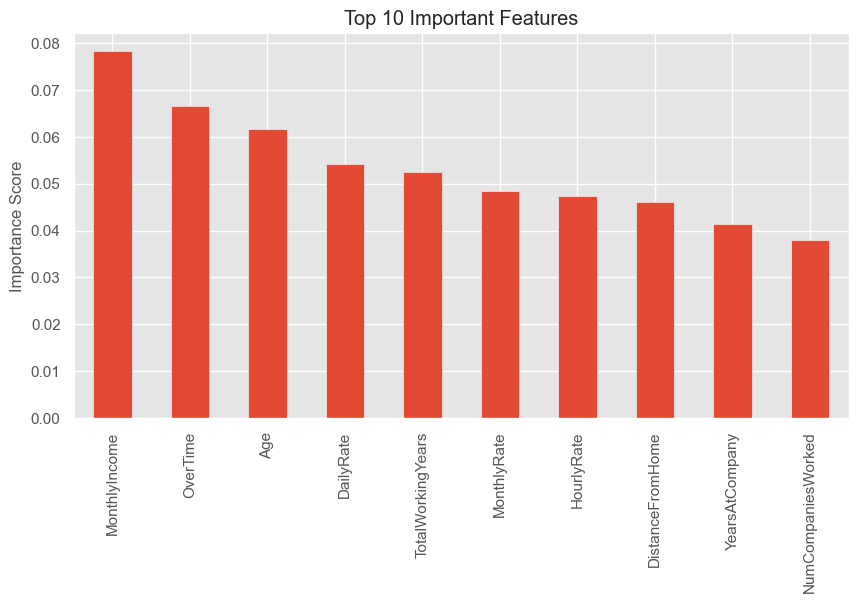

In [62]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

importance.plot(kind='bar')

plt.title('Top 10 Important Features')
plt.ylabel('Importance Score')

plt.show()

# SAVE CLEANED DATASET

In [63]:
df.to_csv('cleaned_hr_attrition.csv', index=False)

print("Cleaned dataset saved")

Cleaned dataset saved
